In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
import lightgbm as lgb
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# DL
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [3]:
# 加载数据
df_train = pd.read_csv("./dataset/train.csv")
df_valid = pd.read_csv("./dataset/val.csv")
df_test = pd.read_csv("./dataset/test.csv")

# 平衡正负例
# smote = SMOTE(sampling_strategy='not majority', random_state=42)
# under_sampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_train = df_train.drop(["HadHeartAttack"], axis=1).values
y_train = df_train[["HadHeartAttack"]].values.ravel()
# X_train, y_train = under_sampler.fit_resample(X_train, y_train)

over_sampler = RandomOverSampler(sampling_strategy="auto", random_state=42)
X_train, y_train = over_sampler.fit_resample(X_train, y_train)

X_valid = df_valid.drop(["HadHeartAttack"], axis=1).values
y_valid = df_valid[["HadHeartAttack"]].values.ravel()

X_test = df_test.drop(["HadHeartAttack"], axis=1).values
y_test = df_test[["HadHeartAttack"]].values.ravel()

print(np.unique(y_train, return_counts=True))

(array([0., 1.]), array([139551, 139551]))


## 线性模型

### 逻辑回归

In [9]:
# 训练
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)

# 测试
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]  # 获取正类的预测概率
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression 测试准确率：%.4f" % acc)
print("Logistic Regression 测试 F1 值：%.4f" % f1)
print("Logistic Regression 测试 Precision 值：%.4f" % precision)
print("Logistic Regression 测试 Recall 值：%.4f" % recall)
print("Logistic Regression 测试 ROC AUC 值：%.4f" % roc_auc)

Logistic Regression 测试准确率：0.8279
Logistic Regression 测试 F1 值：0.3270
Logistic Regression 测试 Precision 值：0.2079
Logistic Regression 测试 Recall 值：0.7659
Logistic Regression 测试 ROC AUC 值：0.8846


## 决策树模型

In [10]:
# 训练
decision_tree = DecisionTreeClassifier(criterion='gini', random_state=42)
decision_tree.fit(X_train, y_train)

# 测试
y_pred = decision_tree.predict(X_test)
y_pred_proba = decision_tree.predict_proba(X_test)[:, 1]  # 获取正类的预测概率
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("CART 测试准确率：%.4f" % acc)
print("CART 测试 F1 值：%.4f" % f1)
print("CART 测试 Precision 值：%.4f" % precision)
print("CART 测试 Recall 值：%.4f" % recall)
print("CART 测试 ROC AUC 值：%.4f" % roc_auc)

CART 测试准确率：0.9180
CART 测试 F1 值：0.2493
CART 测试 Precision 值：0.2493
CART 测试 Recall 值：0.2493
CART 测试 ROC AUC 值：0.6030


## 贝叶斯模型

### 高斯朴素贝叶斯

In [11]:
# 训练
nb = GaussianNB()
nb.fit(X_train, y_train)

# 测试
y_pred = nb.predict(X_test)
y_pred_proba = nb.predict_proba(X_test)[:, 1]  # 获取正类的预测概率
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("高斯朴素贝叶斯 测试准确率：%.4f" % acc)
print("高斯朴素贝叶斯 测试 F1 值：%.4f" % f1)
print("高斯朴素贝叶斯 测试 Precision 值：%.4f" % precision)
print("高斯朴素贝叶斯 测试 Recall 值：%.4f" % recall)
print("高斯朴素贝叶斯 测试 ROC AUC 值：%.4f" % roc_auc)

高斯朴素贝叶斯 测试准确率：0.7965
高斯朴素贝叶斯 测试 F1 值：0.2899
高斯朴素贝叶斯 测试 Precision 值：0.1790
高斯朴素贝叶斯 测试 Recall 值：0.7607
高斯朴素贝叶斯 测试 ROC AUC 值：0.8531


### 多项式朴素贝叶斯

In [12]:
# 训练
nb = MultinomialNB()
nb.fit(X_train, y_train)

# 测试
y_pred = nb.predict(X_test)
y_pred_proba = nb.predict_proba(X_test)[:, 1]  # 获取正类的预测概率
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("多项式朴素贝叶斯 测试准确率：%.4f" % acc)
print("多项式朴素贝叶斯 测试 F1 值：%.4f" % f1)
print("多项式朴素贝叶斯 测试 Precision 值：%.4f" % precision)
print("多项式朴素贝叶斯 测试 Recall 值：%.4f" % recall)
print("多项式朴素贝叶斯 测试 ROC AUC 值：%.4f" % roc_auc)

多项式朴素贝叶斯 测试准确率：0.8039
多项式朴素贝叶斯 测试 F1 值：0.2972
多项式朴素贝叶斯 测试 Precision 值：0.1848
多项式朴素贝叶斯 测试 Recall 值：0.7592
多项式朴素贝叶斯 测试 ROC AUC 值：0.8576


### 伯努利朴素贝叶斯

In [13]:
# 训练
nb = BernoulliNB()
nb.fit(X_train, y_train)

# 测试
y_pred = nb.predict(X_test)
y_pred_proba = nb.predict_proba(X_test)[:, 1]  # 获取正类的预测概率
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("伯努利朴素贝叶斯 测试准确率：%.4f" % acc)
print("伯努利朴素贝叶斯 测试 F1 值：%.4f" % f1)
print("伯努利朴素贝叶斯 测试 Precision 值：%.4f" % precision)
print("伯努利朴素贝叶斯 测试 Recall 值：%.4f" % recall)
print("伯努利朴素贝叶斯 测试 ROC AUC 值：%.4f" % roc_auc)

伯努利朴素贝叶斯 测试准确率：0.7912
伯努利朴素贝叶斯 测试 F1 值：0.2821
伯努利朴素贝叶斯 测试 Precision 值：0.1737
伯努利朴素贝叶斯 测试 Recall 值：0.7514
伯努利朴素贝叶斯 测试 ROC AUC 值：0.8523


## 集成学习

### LightGBM

<https://lightgbm.readthedocs.io/en/latest/index.html>

[LightGBM] [Info] Number of positive: 139551, number of negative: 139551
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020397 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 758
[LightGBM] [Info] Number of data points in the train set: 279102, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 0.249538	valid_0's binary_logloss: 0.38614
LightGBM 测试准确率：0.8228
LightGBM 测试 F1 值：0.3209
LightGBM 测试 Precision 值：0.2029
LightGBM 测试 Recall 值：0.7667
LightGBM 测试 ROC AUC 值：0.8843


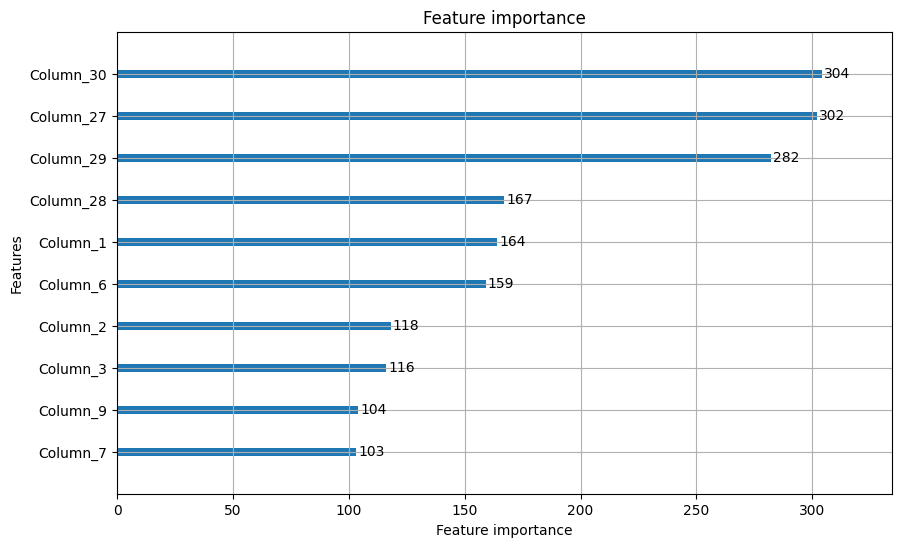

In [5]:
# 训练
gbm = lgb.LGBMClassifier(random_state=42)
gbm.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
        eval_metric="l1",
        callbacks=[lgb.early_stopping(5)]
    )

# 测试
X_test_df = pd.DataFrame(X_test, columns=df_train.drop(["HadHeartAttack"], axis=1).columns)
y_pred = gbm.predict(X_test_df, num_iteration=gbm.best_iteration_)
y_pred_proba = gbm.predict_proba(X_test_df)[:, 1]
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("LightGBM 测试准确率：%.4f" % acc)
print("LightGBM 测试 F1 值：%.4f" % f1)
print("LightGBM 测试 Precision 值：%.4f" % precision)
print("LightGBM 测试 Recall 值：%.4f" % recall)
print("LightGBM 测试 ROC AUC 值：%.4f" % roc_auc)

lgb.plot_importance(gbm, importance_type='split', max_num_features=10, figsize=(10, 6))
plt.show()

### LightGBM 调参

In [ ]:
"""学习率调参"""
acc_lr = []
recall_lr = []
roc_auc_lr = []
ran = np.arange(0.001, 0.101, 0.001)
for lr in ran:
    gbm = lgb.LGBMClassifier(random_state=42, learning_rate=lr)
    gbm.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(5)],
        )
    y_pred_proba = gbm.predict_proba(X_test_df)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    acc_lr.append(acc)
    recall_lr.append(recall)
    roc_auc_lr.append(roc_auc)

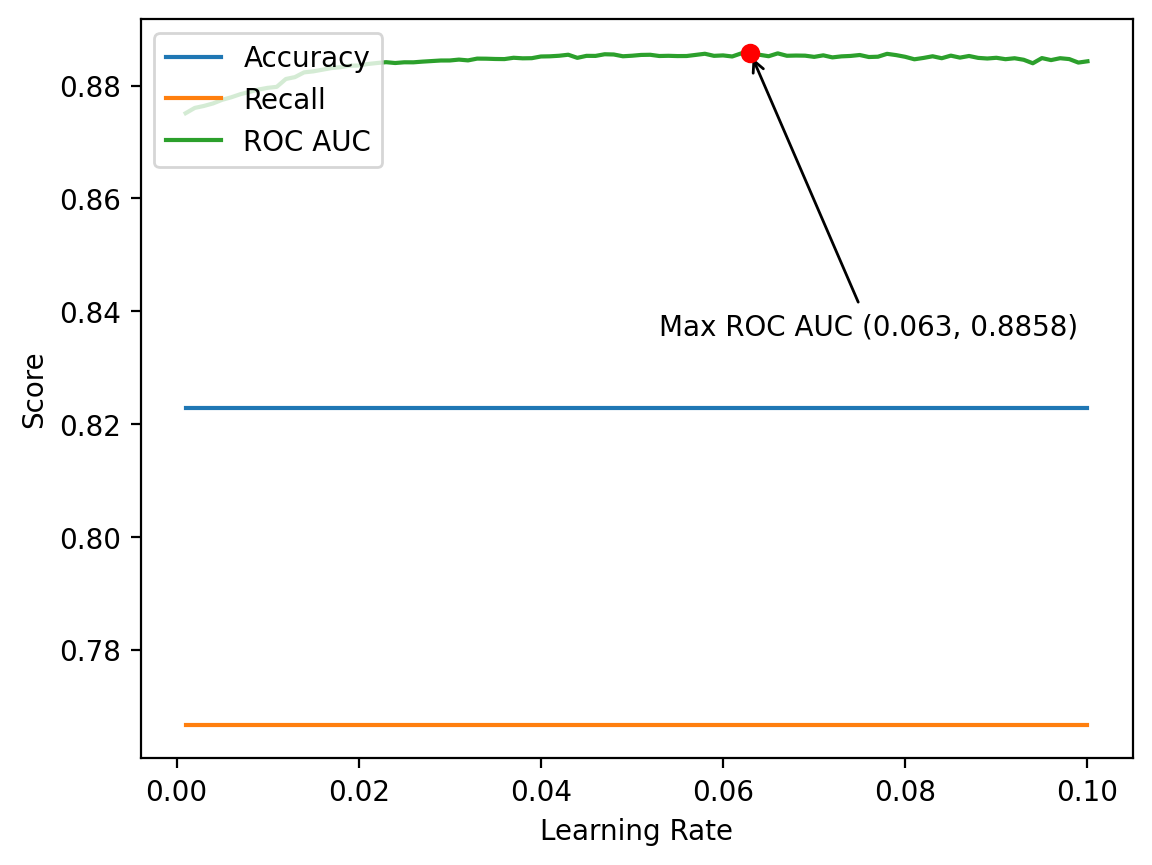

In [38]:
fig, ax = plt.subplots(dpi=200)

ax.plot(ran, acc_lr, label="Accuracy")
ax.plot(ran, recall_lr, label="Recall")
ax.plot(ran, roc_auc_lr, label="ROC AUC")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Score")

max_roc_auc = max(roc_auc_lr)
max_roc_auc_index = roc_auc_lr.index(max_roc_auc)
ax.scatter(ran[max_roc_auc_index], max_roc_auc, color='red', zorder=5)
ax.annotate(f'Max ROC AUC ({ran[max_roc_auc_index]}, {max_roc_auc:.4f})',
             xy=(ran[max_roc_auc_index], max_roc_auc),
             xytext=(ran[max_roc_auc_index] - 0.01, max_roc_auc - 0.05),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)
ax.legend()
plt.show()

In [47]:
"""L1正则化系数调参"""
acc_l1 = []
recall_l1 = []
roc_auc_l1 = []
ran = np.arange(0, 1.1, 0.1)
for l1 in ran:
    gbm = lgb.LGBMClassifier(random_state=42, reg_alpha=l1)
    gbm.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(5)],
        )
    y_pred_proba = gbm.predict_proba(X_test_df)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    acc_l1.append(acc)
    recall_l1.append(recall)
    roc_auc_l1.append(roc_auc)

[LightGBM] [Info] Number of positive: 139551, number of negative: 139551
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017218 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 758
[LightGBM] [Info] Number of data points in the train set: 279102, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 0.249538	valid_0's binary_logloss: 0.38614
[LightGBM] [Info] Number of positive: 139551, number of negative: 139551
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total B

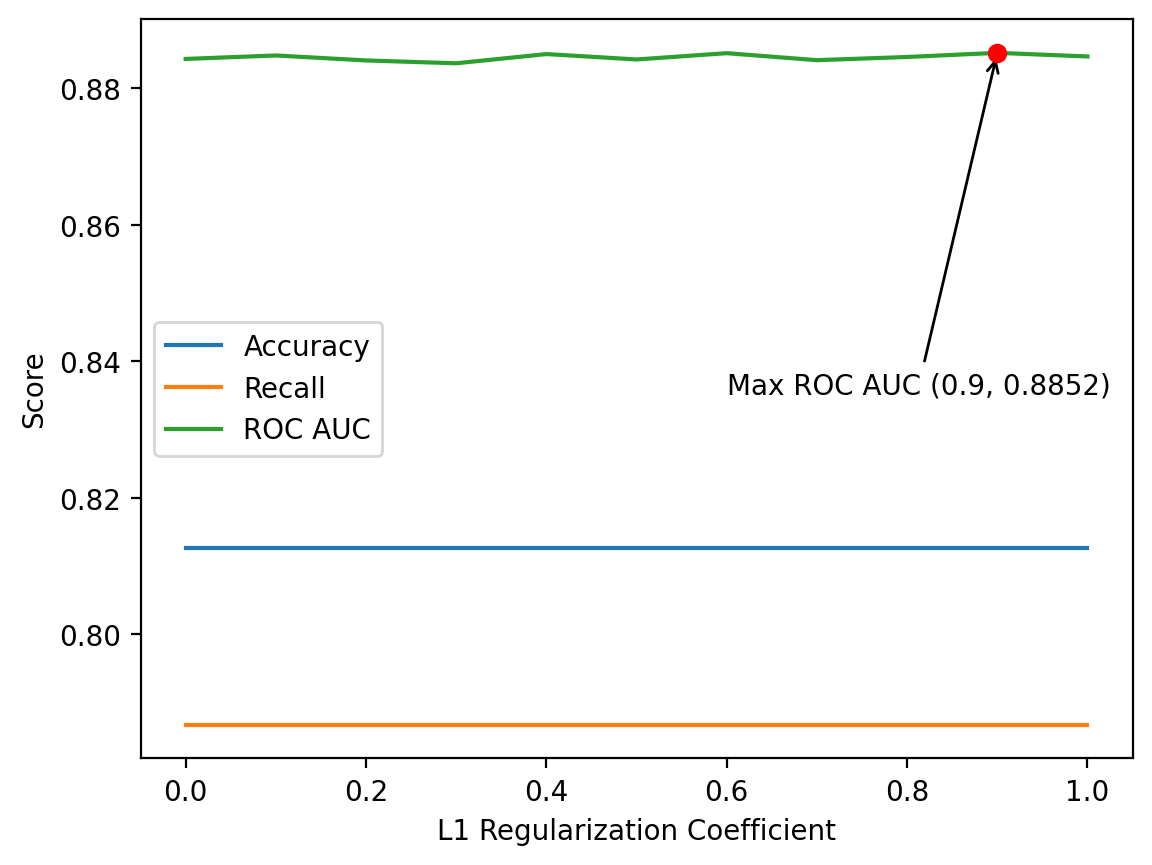

In [48]:
fig, ax = plt.subplots(dpi=200)

ax.plot(ran, acc_l1, label="Accuracy")
ax.plot(ran, recall_l1, label="Recall")
ax.plot(ran, roc_auc_l1, label="ROC AUC")
ax.set_xlabel("L1 Regularization Coefficient")
ax.set_ylabel("Score")

max_roc_auc = max(roc_auc_l1)
max_roc_auc_index = roc_auc_l1.index(max_roc_auc)
ax.scatter(ran[max_roc_auc_index], max_roc_auc, color='red', zorder=5)
ax.annotate(f'Max ROC AUC ({ran[max_roc_auc_index]}, {max_roc_auc:.4f})',
             xy=(ran[max_roc_auc_index], max_roc_auc),
             xytext=(ran[max_roc_auc_index] - 0.3, max_roc_auc - 0.05),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)
ax.legend()
plt.show()

In [41]:
"""L2正则化系数调参"""
acc_l2 = []
recall_l2 = []
roc_auc_l2 = []
ran = np.arange(0, 1.1, 0.1)
for l2 in ran:
    gbm = lgb.LGBMClassifier(random_state=42, reg_lambda=l2)
    gbm.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(5)],
        )
    y_pred_proba = gbm.predict_proba(X_test_df)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    acc_l2.append(acc)
    recall_l2.append(recall)
    roc_auc_l2.append(roc_auc)

[LightGBM] [Info] Number of positive: 139551, number of negative: 139551
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 758
[LightGBM] [Info] Number of data points in the train set: 279102, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 0.249538	valid_0's binary_logloss: 0.38614
[LightGBM] [Info] Number of positive: 139551, number of negative: 139551
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016562 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total B

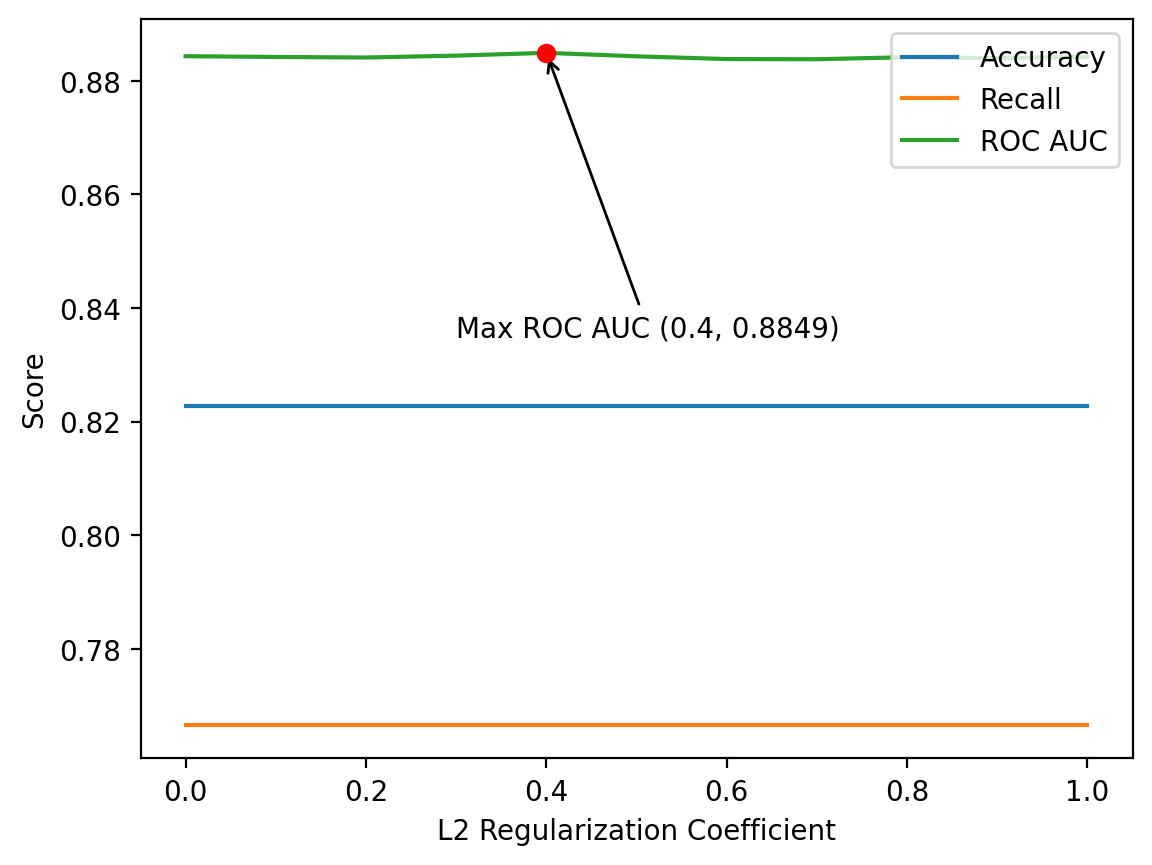

In [42]:
fig, ax = plt.subplots(dpi=200)

ax.plot(ran, acc_l2, label="Accuracy")
ax.plot(ran, recall_l2, label="Recall")
ax.plot(ran, roc_auc_l2, label="ROC AUC")
ax.set_xlabel("L2 Regularization Coefficient")
ax.set_ylabel("Score")

max_roc_auc = max(roc_auc_l2)
max_roc_auc_index = roc_auc_l2.index(max_roc_auc)
ax.scatter(ran[max_roc_auc_index], max_roc_auc, color='red', zorder=5)
ax.annotate(f'Max ROC AUC ({ran[max_roc_auc_index]}, {max_roc_auc:.4f})',
             xy=(ran[max_roc_auc_index], max_roc_auc),
             xytext=(ran[max_roc_auc_index] - 0.1, max_roc_auc - 0.05),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)
ax.legend()
plt.show()

In [43]:
"""树叶数量调参"""
acc_leaves = []
recall_leaves = []
roc_auc_leaves = []
ran = np.arange(10, 101, 1)
for leaves in ran:
    gbm = lgb.LGBMClassifier(random_state=42, num_leaves=leaves)
    gbm.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(5)],
        )
    y_pred_proba = gbm.predict_proba(X_test_df)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    acc_leaves.append(acc)
    recall_leaves.append(recall)
    roc_auc_leaves.append(roc_auc)

[LightGBM] [Info] Number of positive: 139551, number of negative: 139551
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 758
[LightGBM] [Info] Number of data points in the train set: 279102, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 0.263455	valid_0's binary_logloss: 0.407003
[LightGBM] [Info] Number of positive: 139551, number of negative: 139551
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013683 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total 

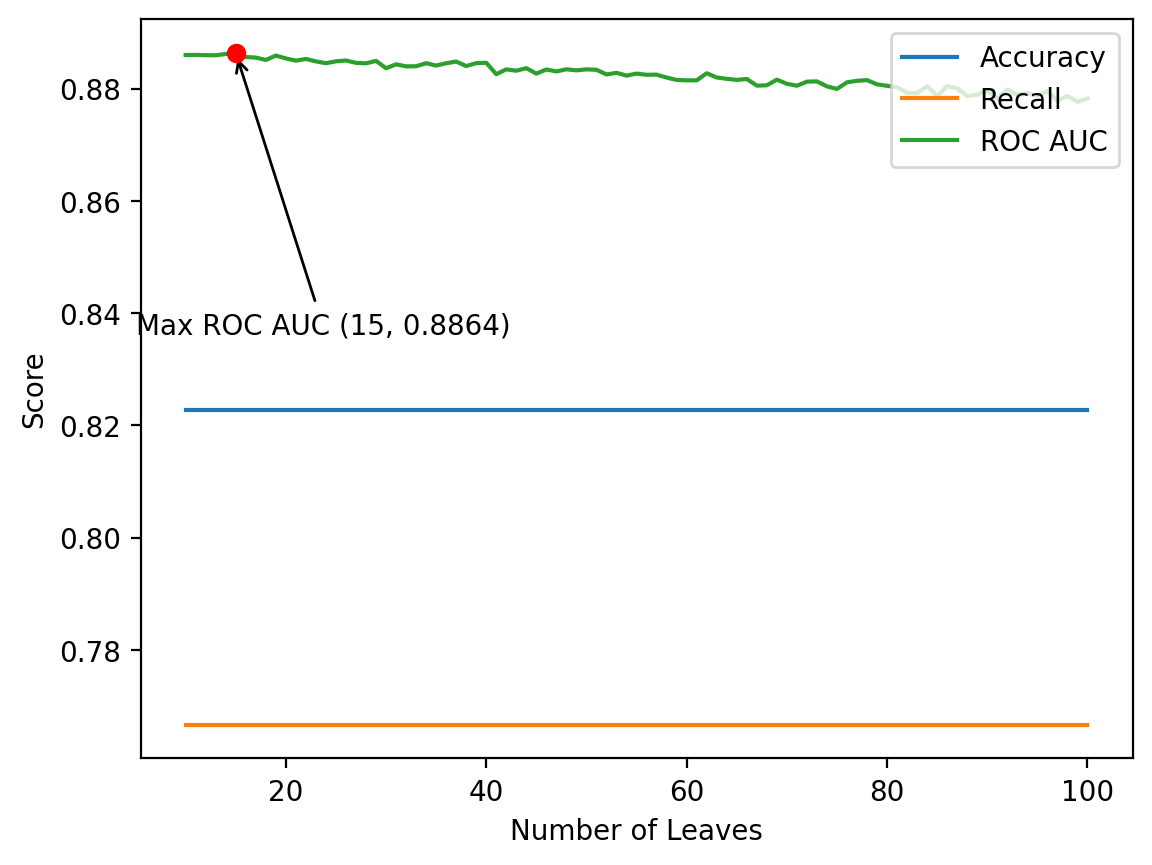

In [44]:
fig, ax = plt.subplots(dpi=200)

ax.plot(ran, acc_leaves, label="Accuracy")
ax.plot(ran, recall_leaves, label="Recall")
ax.plot(ran, roc_auc_leaves, label="ROC AUC")
ax.set_xlabel("Number of Leaves")
ax.set_ylabel("Score")

max_roc_auc = max(roc_auc_leaves)
max_roc_auc_index = roc_auc_leaves.index(max_roc_auc)
ax.scatter(ran[max_roc_auc_index], max_roc_auc, color='red', zorder=5)
ax.annotate(f'Max ROC AUC ({ran[max_roc_auc_index]}, {max_roc_auc:.4f})',
             xy=(ran[max_roc_auc_index], max_roc_auc),
             xytext=(ran[max_roc_auc_index] - 10, max_roc_auc - 0.05),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)
ax.legend()
plt.show()

In [45]:
"""最佳参数模型"""
best_gbm = lgb.LGBMClassifier(random_state=42, learning_rate=0.063,
                         reg_alpha=0.9, reg_lambda=0.4, num_leaves=15)
best_gbm.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(5)],
        )
y_pred_proba = best_gbm.predict_proba(X_test_df)[:, 1]
y_pred = best_gbm.predict(X_test_df, num_iteration=best_gbm.best_iteration_)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("LightGBM 测试准确率：%.4f" % acc)
print("LightGBM 测试 F1 值：%.4f" % f1)
print("LightGBM 测试 Precision 值：%.4f" % precision)
print("LightGBM 测试 Recall 值：%.4f" % recall)
print("LightGBM 测试 ROC AUC 值：%.4f" % roc_auc)

[LightGBM] [Info] Number of positive: 139551, number of negative: 139551
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 758
[LightGBM] [Info] Number of data points in the train set: 279102, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 0.265697	valid_0's binary_logloss: 0.407858
LightGBM 测试准确率：0.8127
LightGBM 测试 F1 值：0.3144
LightGBM 测试 Precision 值：0.1965
LightGBM 测试 Recall 值：0.7868
LightGBM 测试 ROC AUC 值：0.8859


### Adaboost

In [17]:
# 训练
base_classifier = DecisionTreeClassifier(max_depth=5)
ada_boost = AdaBoostClassifier(base_classifier, n_estimators=50, random_state=42)
ada_boost.fit(X_train, y_train)

# 测试
y_pred = ada_boost.predict(X_test)
y_pred_proba = ada_boost.predict_proba(X_test)[:, 1]  # 获取正类的预测概率
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("AdaBoost 测试准确率：%.4f" % acc)
print("AdaBoost 测试 F1 值：%.4f" % f1)
print("AdaBoost 测试 Precision 值：%.4f" % precision)
print("AdaBoost 测试 Recall 值：%.4f" % recall)
print("AdaBoost 测试 ROC AUC 值：%.4f" % roc_auc)

AdaBoost 测试准确率：0.7988
AdaBoost 测试 F1 值：0.2905
AdaBoost 测试 Precision 值：0.1799
AdaBoost 测试 Recall 值：0.7544
AdaBoost 测试 ROC AUC 值：0.8693


### XGBoost

In [40]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt

# 训练
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# 测试
X_test_df = pd.DataFrame(X_test, columns=df_train.drop(["HadHeartAttack"], axis=1).columns)
y_pred = xgb_model.predict(X_test_df)
y_pred_proba = xgb_model.predict_proba(X_test_df)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("XGBoost 测试准确率：%.4f" % acc)
print("XGBoost 测试 F1 值：%.4f" % f1)
print("XGBoost 测试 Precision 值：%.4f" % precision)
print("XGBoost 测试 Recall 值：%.4f" % recall)
print("XGBoost 测试 ROC AUC 值：%.4f" % roc_auc)

# 特征重要性可视化
# xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10, figsize=(10, 6))
# plt.show()

XGBoost 测试准确率：0.8507
XGBoost 测试 F1 值：0.3379
XGBoost 测试 Precision 值：0.2230
XGBoost 测试 Recall 值：0.6974
XGBoost 测试 ROC AUC 值：0.8662


### 随机森林

In [18]:
# 训练
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 测试
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]  # 获取正类的预测概率
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("RandomForest 测试准确率：%.4f" % acc)
print("RandomForest 测试 F1 值：%.4f" % f1)
print("RandomForest 测试 Precision 值：%.4f" % precision)
print("RandomForest 测试 Recall 值：%.4f" % recall)
print("RandomForest 测试 ROC AUC 值：%.4f" % roc_auc)

RandomForest 测试准确率：0.9465
RandomForest 测试 F1 值：0.3801
RandomForest 测试 Precision 值：0.5176
RandomForest 测试 Recall 值：0.3003
RandomForest 测试 ROC AUC 值：0.8670


## 懒惰学习

In [19]:
# 训练
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 测试
y_pred = knn.predict(X_test)
y_pred_proba = knn.predict_proba(X_test)[:, 1]  # 获取正类的预测概率
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("K近邻 测试准确率：%.4f" % acc)
print("K近邻 测试 F1 值：%.4f" % f1)
print("K近邻 测试 Precision 值：%.4f" % precision)
print("K近邻 测试 Recall 值：%.4f" % recall)
print("K近邻 测试 ROC AUC 值：%.4f" % roc_auc)

K近邻 测试准确率：0.8812
K近邻 测试 F1 值：0.2968
K近邻 测试 Precision 值：0.2193
K近邻 测试 Recall 值：0.4592
K近邻 测试 ROC AUC 值：0.7206


## 深度模型

### FNN

In [20]:
"""模型搭建"""
class FNN(nn.Module):
    def __init__(self, feat_num):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(feat_num, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return self.sigmoid(x)

"""数据重构"""
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.bool)
X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.bool)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.bool)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

In [26]:
"""开始训练"""
wandb.init(project='heart-disease-prediction', name='run')
model = FNN(feat_num=X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()
num_epochs = 3
best_valid_accuracy = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # 训练阶段
    for step, (inputs, labels) in enumerate(train_loader):
        optimizer.zero_grad()  # 清除梯度
        outputs = model(inputs).squeeze()  # 计算预测值
        loss = criterion(outputs, labels.float())  # 计算损失
        loss.backward()  # 反向传播
        optimizer.step()  # 更新参数

        running_loss += loss.item()

        # 计算准确率
        predicted = (outputs > 0.5).float()  # 二分类阈值设置为0.5
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # 记录每个 step 的训练损失和准确率
        train_accuracy = correct / total
        wandb.log({
            'train_loss': loss.item(),
            'train_accuracy': train_accuracy,
            'epoch': epoch + 1,
            'step': step + 1,
        })

    # 计算训练集的损失和准确率
    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    # 验证阶段
    model.eval()
    valid_correct = 0
    valid_total = 0
    valid_loss = 0

    with torch.no_grad():  # 评估时不需要计算梯度
        for inputs, labels in valid_loader:
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels.float())
            valid_loss += loss.item()

            predicted = (outputs > 0.5).float()
            valid_correct += (predicted == labels).sum().item()
            valid_total += labels.size(0)

    # 计算验证集的损失和准确率
    valid_loss = valid_loss / len(valid_loader)
    valid_accuracy = valid_correct / valid_total

    # 记录每个 epoch 的训练和验证数据
    wandb.log({
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'valid_loss': valid_loss,
        'valid_accuracy': valid_accuracy,
        'epoch': epoch + 1,
    })

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}, Valid Accuracy: {valid_accuracy:.4f}")

    # 保存最好的模型
    if valid_accuracy > best_valid_accuracy:
        best_valid_accuracy = valid_accuracy
        torch.save(model.state_dict(), "./models/best-fnn-model.pth")

wandb.finish()

Epoch 1/3
Train Loss: 0.4064, Train Accuracy: 0.8124
Valid Loss: 0.3875, Valid Accuracy: 0.8233
Epoch 2/3
Train Loss: 0.3769, Train Accuracy: 0.8312
Valid Loss: 0.3785, Valid Accuracy: 0.8309
Epoch 3/3
Train Loss: 0.3643, Train Accuracy: 0.8394
Valid Loss: 0.3707, Valid Accuracy: 0.8371


epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅████████████████
step,▁▂▂▃▃▄▆▆▆▆▇██▁▂▂▂▃▃▃▃▃▃▄▄▅▆▆▆▆▇▁▂▂▃▄▅▆▆█
train_accuracy,▁▃▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▄▄▃▄▅▄▅▄▃▅▃▅▂▄▆▃▃▂▃▃▂▃▃▃▄▁▄▃▂▃▁▂▅▂▁▄▃▂▂
valid_accuracy,▁▅█
valid_loss,█▄▁
epoch,3
step,4361
train_accuracy,0.83941
train_loss,0.36425
valid_accuracy,0.83714


In [22]:
"""模型测试"""
model = FNN(feat_num=X_train.shape[1])
model.load_state_dict(torch.load("./models/best-fnn-model.pth"))
model.eval()

test_correct = 0
test_total = 0

TP, FP, TN, FN = 0, 0, 0, 0
y_true = []
y_pred = []

with torch.no_grad():
    outputs = model(X_test_tensor).squeeze()
    predicted = (outputs > 0.5).float()

    TP += ((predicted == 1) & (y_test_tensor == 1)).sum().item()
    FP += ((predicted == 1) & (y_test_tensor == 0)).sum().item()
    TN += ((predicted == 0) & (y_test_tensor == 0)).sum().item()
    FN += ((predicted == 0) & (y_test_tensor == 1)).sum().item()

    test_correct += (predicted == y_test_tensor).sum().item()
    test_total += y_test_tensor.size(0)

    y_true.extend(y_test_tensor.cpu().numpy())  # 添加真实标签
    y_pred.extend(predicted.cpu().numpy())  # 添加预测标签

# 计算 F1-score
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# 计算准确率
test_accuracy = test_correct / test_total

# 计算 ROC AUC
roc_auc = roc_auc_score(y_true, y_pred)

print("FNN 测试准确率：%.4f" % test_accuracy)
print("FNN 测试 F1-score：%.4f" % f1)
print("FNN 测试 Precision：%.4f" % precision)
print("FNN 测试 Recall：%.4f" % recall)
print("FNN 测试 ROC AUC：%.4f" % roc_auc)

FNN 测试准确率：0.8158
FNN 测试 F1-score：0.3027
FNN 测试 Precision：0.1908
FNN 测试 Recall：0.7324
FNN 测试 ROC AUC：0.7765
